# EPC 与 Eliashberg 交互教程
Electron-Phonon Coupling and Isotropic Imaginary-Axis Eliashberg Theory

先修：BCS 能隙、矩阵本征值、Python。目标：解释谱矩、虚轴方程和基准证据。
Al 官方参考、Einstein 教学模型、Pb 粗网格集群回归是三个不同问题。
本 Notebook 不扫描 DFT 密度/截断/展宽，不声称预测 Pb Tc。
建议先写自己的预期，再运行每节。详细推导及答案在同目录中文教程。

## 1. 明确数据来源与单位
预测：Ry 横轴转为 meV，A 是否也要缩放？DOS 呢？

In [1]:
from pathlib import Path
import json, hashlib
import numpy as np
import matplotlib.pyplot as plt
from epc import (load_spectrum, moments, qe_rectangle_moments, tc_estimates,
                 einstein_kernel, instability, find_tc, solve_gap, RY_TO_MEV)
from cluster.pb_regression.validate_epw import check_log, check_table
root = Path.cwd()
source = root/'reference/qe-7.5/PHonon/examples/tetra_example/reference/aluminum.a2F.dat'
w, a = load_spectrum(source, 'Ry', 1)
al = moments(w, a)
print('Official Al reference, NOT our earlier Al SCF:', source.name)
print('Energy range (meV):', al['integration_range_meV'])
print('lambda / omega_log / omega2:', al['lambda'], al['omega_log_meV'], al['omega2_meV'])
assert np.all(np.diff(w) > 0) and np.all(a >= 0)

Official Al reference, NOT our earlier Al SCF: aluminum.a2F.dat
Energy range (meV): [0.07850727802801967, 39.253639014009764]
lambda / omega_log / omega2: 0.39621339231277314 26.530723328419835 29.12235321575053


## 2. 重建参考积分
原输出采用完整格点宽度求和，梯形规则首尾减半。先解释不同，再比较参考。

Trapezoid: 0.39621339231277314
Reference bin sum: 0.3963915104345086
Difference: 0.00017811812173545993


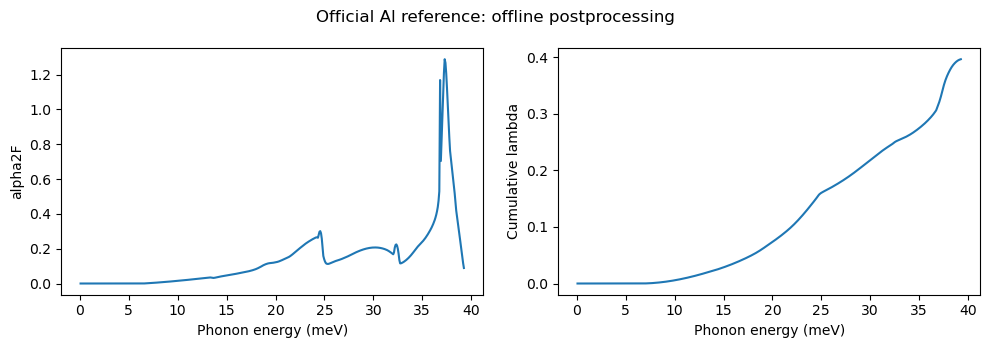

In [2]:
rectangle = qe_rectangle_moments(w, a)
assert abs(rectangle['lambda']-0.3963915104345056) < 1e-6
print('Trapezoid:', al['lambda'])
print('Reference bin sum:', rectangle['lambda'])
print('Difference:', rectangle['lambda']-al['lambda'])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(w, a); axes[0].set(xlabel='Phonon energy (meV)', ylabel='alpha2F')
axes[1].plot(w, al['cumulative_lambda']); axes[1].set(xlabel='Phonon energy (meV)', ylabel='Cumulative lambda')
fig.suptitle('Official Al reference: offline postprocessing')
plt.tight_layout(); plt.show()

## 3. 两种近似 Tc，不是解方程
完整 Allen-Dynes 有 f1/f2。μ*=0.1 是假设，不是 SCF 化学势。

In [3]:
formula = tc_estimates(al['lambda'], al['omega_log_meV'], al['omega2_meV'], 0.1)
for key, value in formula.items():
    print(key, value)
assert formula['allen_dynes_K'] != formula['modified_mcmillan_K']
assert formula['is_eliashberg_solution'] is False

mu_star 0.1
modified_mcmillan_K 1.223846853700345
allen_dynes_K 1.2416681472917626
f1 1.013117968251919
f2 1.001425040451123
is_eliashberg_solution False


## 4. 独立 Einstein 模型的核
A(Ω)=λΩE δ(Ω−ΩE)/2；K(ν)=λΩE²/(ΩE²+ν²)。
选择 λ=1、ΩE=10 meV、μ*=0.1，固定 96 个正虚频、库仑截止 100 meV。
没有把这些参数称为 Al 或 Pb。检查偶对称和 K(0)=λ。

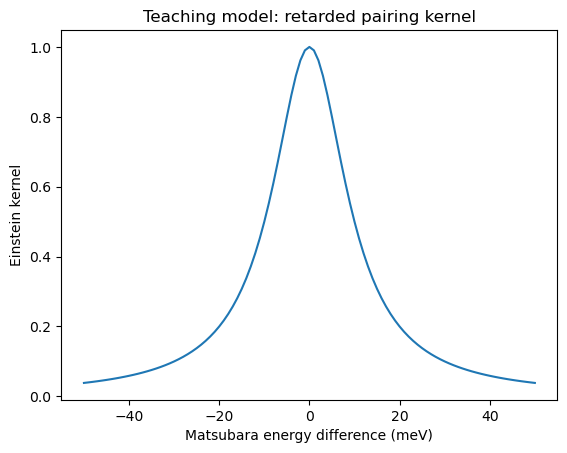

In [4]:
nu = np.linspace(-50, 50, 101)
kernel = einstein_kernel(nu, 1, 10)
assert np.allclose(kernel, kernel[::-1])
assert einstein_kernel(0, 1, 10) == 1
plt.plot(nu, kernel)
plt.xlabel('Matsubara energy difference (meV)'); plt.ylabel('Einstein kernel')
plt.title('Teaching model: retarded pairing kernel'); plt.show()

## 5. 线性不稳定性与有限模型 Tc
最大实本征值过 1。区间宽度不是截止误差或材料误差。

In [5]:
for T in [2, 10, 25]:
    print(T, instability(T, 1, 10, .1))
tc = find_tc(2, 25, 1, 10, .1)
print('Finite-model Tc bracket (K):', tc['lower_K'], tc['upper_K'])
assert tc['upper_K']-tc['lower_K'] <= .01
assert tc['is_material_prediction'] is False and tc['matsubara_cutoff_converged'] is False

2 {'eigenvalue': 1.6823331783435764, 'eigen_residual': 6.661338147750939e-16}
10 {'eigenvalue': 0.9662639502714855, 'eigen_residual': 2.220446049250313e-16}
25 {'eigenvalue': 0.603293851485989, 'eigen_residual': 3.3306690738754696e-16}
Finite-model Tc bracket (K): 9.260498046875 9.26611328125


## 6. 非线性 Δ(iω)、Z(iω)
在 4 K 求原方程残差。在 12 K 检查正常态。Δ(iω0) 不是实轴能隙。

4 K fixed-point residual: 9.346273754928802e-09 4.5417891669785604e-10


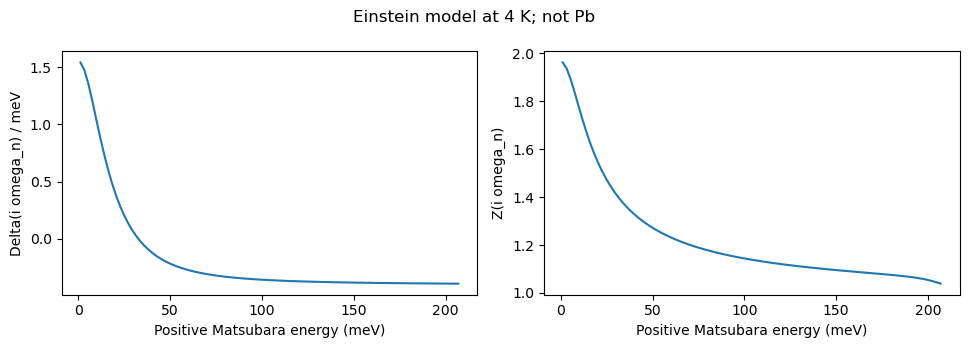

In [6]:
solution = solve_gap(4, 1, 10, .1)
normal = solve_gap(12, 1, 10, .1)
print('4 K fixed-point residual:', solution['gap_residual_meV'], solution['Z_residual'])
assert solution['gap_residual_meV'] < 1e-8 and solution['Z_residual'] < 1e-9
assert normal['superconducting'] is False and max(abs(np.array(normal['gap_meV']))) == 0
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(solution['frequency_meV'], solution['gap_meV']); axes[0].set(xlabel='Positive Matsubara energy (meV)', ylabel='Delta(i omega_n) / meV')
axes[1].plot(solution['frequency_meV'], solution['Z']); axes[1].set(xlabel='Positive Matsubara energy (meV)', ylabel='Z(i omega_n)')
fig.suptitle('Einstein model at 4 K; not Pb'); plt.tight_layout(); plt.show()

## 7. 真实 Pb 粗网格回归证据
读取 Job 313824 的完整物理输出：程序已结束，但当时后检查误读文件尾部使作业 FAILED。
修正后的同参数 Job 313836 COMPLETED，其谱与此谱 SHA256 完全相同。
复用上游 DFPT，自己的 SCF/NSCF/EPW。不要把它改名为材料 Tc 预测。

In [7]:
pbroot = root/'cluster/pb_regression'
record = json.loads((pbroot/'results/cluster_record.json').read_text(encoding='utf-8'))
for item in record['files']:
    assert hashlib.sha256((pbroot/item['path']).read_bytes()).hexdigest() == item['sha256']
spectrum = pbroot/'results/pb.a2f.01.300.000'
assert check_table(spectrum.read_text(), 'epw_legacy') == 500
pw, pa = load_spectrum(spectrum, 'meV', 1, 'epw_legacy')
pb = moments(pw, pa)
log_lambda = check_log((pbroot/'results/output').read_text())
print('mode/q sum lambda:', log_lambda, 'spectrum lambda:', pb['lambda'])
print('upstream benchmark difference:', abs(log_lambda-0.1608789))
for attempt in record['attempts']:
    print(attempt['job_id'], attempt['state'], attempt['reason'])
assert record['attempts'][-1]['state'] == 'COMPLETED'

mode/q sum lambda: 0.1608797 spectrum lambda: 0.16088552858296762
upstream benchmark difference: 7.99999999995249e-07
313822 FAILED EPW output was incorrectly required to contain PW JOB DONE marker
313824 FAILED Numeric parser did not recognize textual EPW legacy spectrum footer
313836 COMPLETED Same fixed physical inputs, corrected completion checker


## 8. 用反例检查，而不是只看平滑曲线
未知单位、零频、负谱和无 Tc bracket 必须失败，不静默修补。

In [8]:
rejected = 0
for action in [lambda: load_spectrum(source, 'unknown'),
               lambda: moments(np.array([0., 1.]), np.array([0., 1.])),
               lambda: moments(np.array([1., 2.]), np.array([.1, -.1])),
               lambda: find_tc(2, 25, 0, 10, 0)]:
    try:
        action()
    except ValueError as error:
        rejected += 1
        print(type(error).__name__, str(error))
assert rejected == 4
print('Scope: reference postprocessing + fixed model + coarse software regression, NOT material Tc.')

ValueError Declare frequency units: Ry, eV, or meV
ValueError Need finite positive strictly increasing frequencies and nonnegative alpha2F
ValueError Need finite positive strictly increasing frequencies and nonnegative alpha2F
ValueError Need superconducting lower bound and normal upper bound
Scope: reference postprocessing + fixed model + coarse software regression, NOT material Tc.


## 课后验收
手算一次单位变换；推导正频率折叠中的库仑因子 2；解释原方程残差；
说明一次 Slurm FAILED 为什么仍有物理输出，以及为什么必须保留失败身份。
最后写出当前尚未完成的一项材料计算证据和一项原论文复现证据。

不要覆盖归档输入来练习参数。用自己的副本保存实验，完整材料流程见 Pb 中文说明。